In [1]:
import pandas as pd
import numpy as np
import functions_for_analyze as ffa
import single_output_parser as sop
import os
import matplotlib.pyplot as pp
from importlib import reload
from matplotlib.colors import TABLEAU_COLORS 
import _daily_reporters as dr
import json
from __visuals__ import matplot
from __visuals__ import _printing_and_display_functions as pad
import _interaction_functions as IF
import _Plot_from_Tables as PFT
import pickle

%matplotlib widget

In [3]:
style_sheet = "./__visuals__/f12xg_plot_style.mplstyle"
pp.style.use(style_sheet)

In [4]:
def gen_fig_title(sysd, plot_type="Interaction energies"):
    return f"{sysd['mono1_name']}-{sysd['mono2_name']} {plot_type}"

def gen_fig_fname(sysd, ext='svg', plot_type="Interaction_energies", folder=None):
    fname= f"{sysd['mono1_name']}_{sysd['mono2_name']}_{plot_type}.{ext}"
    if folder is None:
        folder = '__Analysis_Outputs__/'
    fname = os.path.join(folder, fname)
    return fname

# DFMP2 for Ne-Ar interactions

In [5]:
method='dfmp2'

sysd = dict(
        mono1_name = 'Ar',
        mono2_name = 'Ne',
        dimer_dir = 'ne_ar',
        mono1_dir = 'ne/',
        mono2_dir = 'ar/',
        method_dir = method,
        cores = ['all electron', 'frozen']
        )

In [7]:
reload(PFT)
sysd_core_valence = dict(sysd)
sysd_core_valence['basename'] = 'bse_data_core_valence.csv',
sysd_core_valence['outbasename'] ='dimer_and_monomer_core_valence'

dfs_core_valence = PFT.get_dfs(sysd_core_valence)

# ==== Now pVXZ basis
sysd_pV = dict(sysd)
sysd_pV['basename'] = 'bse_data_valence.csv',
sysd_pV['outbasename'] ='dimer_and_monomer_valence'

dfs_pV = PFT.get_dfs(sysd_pV)
#plot_core

## Interaction energies

### Filter and get plot data

In [8]:
filter_specs=dict(
    cross_filters={
        "func_kwargs": [
            dict(totkey=("HF + ", "CorrE(CBS)")), 
            dict(totkey=("Reference Energy", "5"))
        ],
        "core": ["all electron", "frozen"],
    },
)

In [9]:
reload(IF)
filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data = IF.collect_interaction_data(dfs_pV, filters)
filter_specs['common_filter'] = {"basis": "aug-cc-pwCVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data += IF.collect_interaction_data(dfs_core_valence, filters)

"""
for x,y, labels in plot_data:
    print(f"{labels}")
    print(x[0], x[-1])
    print(y[0], y[-1])
#"""


'\nfor x,y, labels in plot_data:\n    print(f"{labels}")\n    print(x[0], x[-1])\n    print(y[0], y[-1])\n#'

In [10]:
styles0 = {# common styles for all
    "basis" : {
        "aug-cc-pVXZ" : dict(color='tab:blue', label='pVXZ', linewidth=2),
        "aug-cc-pwCVXZ" : dict(color='tab:orange', label='pwCVXZ'),
    },
    "core" : {
        "frozen" : dict(marker='x', label='frozen'),
        "all electron"  : dict(marker='s', fillstyle='none', label='all e')
    }
}

styles = dict(styles0)
styles.update(
    {
        "totkey": {
            ("HF + ", "CorrE(CBS)") : dict(linestyle='-', label='HF5+CBS'),
            ("Reference Energy", "5") : dict(linestyle=':', label='HF5'),
        }
    }
)
                                         

### Plot with Legend

Text(0.5, 0.98, 'Ar-Ne Interaction energies')

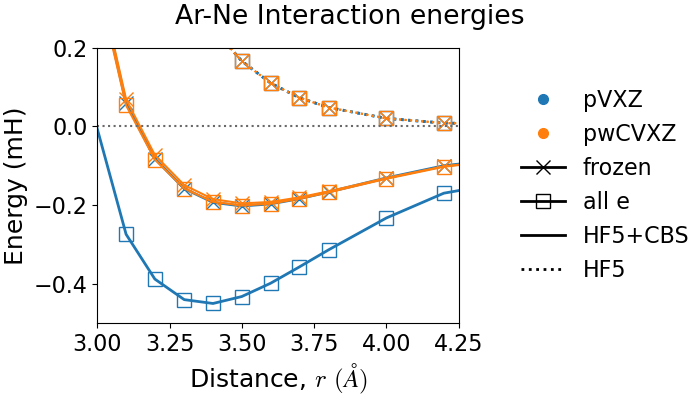

In [11]:
reload(PFT)
fig, ax, leg_ax = PFT.plot_with_external_style_legend(plot_data, styles, convert=10**(3))
ax.set_ylim(-0.5, 0.2)
ax.set_ylabel(rf"Energy (mH)")
ax.set_xlim(3,4.25)
ax.set_xlabel(r"Distance, $r$ $(\AA)$")
fig.suptitle(gen_fig_title(sysd))

### Save figure

#### Save to `__Analysis_Outputs__`

In [ ]:
fname = gen_fig_fname(sysd)
print(fname)
#fig.savefig(fname)


In [ ]:
fname = gen_fig_fname(sysd, ext='pkl')
with open(fname, 'wb') as f:
    pickle.dump(fig, f)



#### Save to dailies

In [ ]:
with open(dr.gen_fname(os.path.basename(fname),ext='pkl'), 'wb') as f:
    pickle.dump(fig, f)

### Load previous figure for comparison

In [ ]:
fname = gen_fig_fname(sysd, ext='pkl')
with open(fname, 'rb') as f:
    lfig = pickle.load(f)
lfig

## BSE at given distances

### Exploring at 3.4 and 9.0

In [12]:

filter_specs=dict(
    cross_filters={
        "func_kwargs": [
            dict(distance='3.4', exp=3), 
            dict(distance='9.0', exp=3)
        ],
        "core": ["all electron", "frozen"],
    },
)

styles = dict(styles0)
styles.update(
    {
        "distance": {
            "3.4" : dict(linestyle='-', label='$r=3.4$'),
            "9.0" : dict(linestyle=':', label='$r=9.0$'),
        }
    }       
)

In [13]:
reload(IF)
filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data = IF.collect_interaction_data(dfs_pV, filters, func=IF.get_cbs_data)
filter_specs['common_filter'] = {"basis": "aug-cc-pwCVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data += IF.collect_interaction_data(dfs_core_valence, filters, func=IF.get_cbs_data)
 
for x,y, labels in plot_data:
    print(f"{labels}")
    print(x[0], x[-1])
    print(y[0], y[-1])

{'basis': 'aug-cc-pVXZ', 'distance': '3.4', 'exp': 3, 'core': 'all electron'}
0.125 0.0
-0.36996206845 -0.8985482796444263
{'basis': 'aug-cc-pVXZ', 'distance': '3.4', 'exp': 3, 'core': 'frozen'}
0.125 0.0
-0.361517865953 -0.5704312851349342
{'basis': 'aug-cc-pVXZ', 'distance': '9.0', 'exp': 3, 'core': 'all electron'}
0.125 0.0
-0.36958331819 -0.8978512344451803
{'basis': 'aug-cc-pVXZ', 'distance': '9.0', 'exp': 3, 'core': 'frozen'}
0.125 0.0
-0.361178381862 -0.5699907203469999
{'basis': 'aug-cc-pwCVXZ', 'distance': '3.4', 'exp': 3, 'core': 'all electron'}
0.125 0.0
-0.56992621686 -1.0995865466422947
{'basis': 'aug-cc-pwCVXZ', 'distance': '3.4', 'exp': 3, 'core': 'frozen'}
0.125 0.0
-0.383800290921 -0.572097760936623
{'basis': 'aug-cc-pwCVXZ', 'distance': '9.0', 'exp': 3, 'core': 'all electron'}
0.125 0.0
-0.569557305946 -1.0991470436947868
{'basis': 'aug-cc-pwCVXZ', 'distance': '9.0', 'exp': 3, 'core': 'frozen'}
0.125 0.0
-0.383466201023 -0.5716650817141803


Text(0.5, 0.98, 'Ar-Ne BSE')

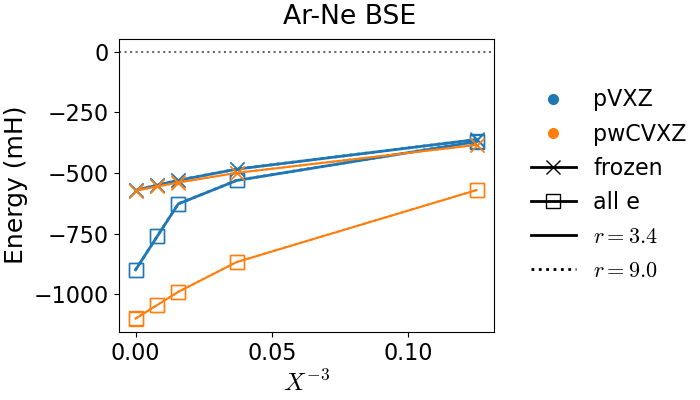

In [14]:


reload(PFT)
fig, ax, leg_ax = PFT.plot_with_external_style_legend(plot_data, styles, convert=10**(3))
#ax.set_ylim(-0.5, 0.2)
ax.set_ylabel(rf"Energy (mH)")
ax.set_xlabel(r"$X^{-3}$")
#ax.set_ylim(-0.5, 0.2)
#ax.set_xlim(3,4.25)

fig.suptitle(gen_fig_title(sysd, plot_type='BSE'))

#### Save to `__Analysis_Outputs__`

In [ ]:
fname = gen_fig_fname(sysd, plot_type="BSE")
print(fname)
fig.savefig(fname)


In [ ]:
fname = gen_fig_fname(sysd, plot_type='BSE', ext='pkl')
with open(fname, 'wb') as f:
    pickle.dump(fig, f)

#### Save to dailies

In [ ]:
with open(dr.gen_fname(os.path.basename(fname),ext='pkl'), 'wb') as f:
    pickle.dump(fig, f)

### Difference between 3.4 and 9.0

In [ ]:

filter_specs=dict(
    cross_filters={
        "core": ["all electron", "frozen"],
    },
)

styles = dict(styles0)
styles.update({})

In [ ]:
reload(IF)
def diff_func(*args, dist1="3.4", dist2="9.0", **kwargs):
    _, y1 = IF.get_cbs_data(*args, distance=dist1, **kwargs)
    xdata, y2 = IF.get_cbs_data(*args, distance=dist2, **kwargs)
    return xdata, y2 - y1
    
filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ", "func_kwargs" : dict(dist1="3.4", dist2="9.0") }
filters = ffa.expand_filter_grid(**filter_specs)
plot_data = IF.collect_interaction_data(dfs_pV, filters, func=diff_func)
filter_specs['common_filter'] = {"basis": "aug-cc-pwCVXZ", "func_kwargs" : dict(dist1="3.4", dist2="9.0") }
filters = ffa.expand_filter_grid(**filter_specs)
plot_data += IF.collect_interaction_data(dfs_core_valence, filters, func=diff_func)


In [ ]:
reload(PFT)
fig, ax, leg_ax = PFT.plot_with_external_style_legend(plot_data, styles, convert=10**(3))
#ax.set_ylim(-0.5, 0.2)
ax.set_ylabel(rf"$\Delta$ Energy (mH)")
ax.set_xlabel(r"$X^{-3}$")
#ax.set_ylim(-0.5, 0.2)
#ax.set_xlim(3,4.25)

fig.suptitle(gen_fig_title(sysd, plot_type=f'BSE(9.0) - BSE(3.4)'))

#### Save to `__Analysis_Outputs__`

In [ ]:
fname = gen_fig_fname(sysd, plot_type="Diff_BSE")
print(fname)
fig.savefig(fname)


In [ ]:
fname = gen_fig_fname(sysd, plot_type='Diff_BSE', ext='pkl')
with open(fname, 'wb') as f:
    pickle.dump(fig, f)

#### Save to dailies

In [ ]:
with open(dr.gen_fname(os.path.basename(fname),ext='pkl'), 'wb') as f:
    pickle.dump(fig, f)

# F12

In [15]:
method='f12'

sysd = dict(
        mono1_name = 'Ar',
        mono2_name = 'Ne',
        dimer_dir = 'ne_ar',
        mono1_dir = 'ne/',
        mono2_dir = 'ar/',
        method_dir = method,
        cores = ['all electron', 'frozen']
        )

In [16]:
reload(PFT)
sysd_core_valence = dict(sysd)
sysd_core_valence['basename'] = 'bse_data_core_valence.csv',
sysd_core_valence['outbasename'] ='dimer_and_monomer_core_valence'

dfs_core_valence = PFT.get_dfs(sysd_core_valence)

# ==== Now pVXZ basis
#sysd_pV = dict(sysd)
#sysd_pV['basename'] = 'bse_data_valence.csv',
#sysd_pV['outbasename'] ='dimer_and_monomer'

#dfs_pV = PFT.get_dfs(sysd_pV)
#plot_core

## Interaction energies

### Filter and get plot data

In [17]:
filter_specs=dict(
    cross_filters={
        "func_kwargs": [
            dict(totkey=("HF + ", "CorrE(CBS)")), 
            dict(totkey=("Reference Energy", "5"))
        ],
        "core": ["all electron", "frozen"],
    },
)

In [18]:
reload(IF)
#filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ"}
#filters = ffa.expand_filter_grid(**filter_specs)
#plot_data = IF.collect_interaction_data(dfs_pV, filters)
filter_specs['common_filter'] = {"basis": "aug-cc-pwCVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data = IF.collect_interaction_data(dfs_core_valence, filters)

"""
for x,y, labels in plot_data:
    print(f"{labels}")
    print(x[0], x[-1])
    print(y[0], y[-1])
#"""


/home/linux3_i1/amin/00_WORKSPACE/test_f12/main/systems/_interaction_functions.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  dfsum = df.loc[sumkey]


KeyError: 'Sum'